In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv(r'C:\Users\SHYAM SASHANK\OneDrive\Desktop\Data_Science\Assginment_CSV\CocaCola_Sales.csv')

In [3]:
df

,Quarter,Sales
0,Q1_86,1734.827000
1,Q2_86,2244.960999
2,Q3_86,2533.804993
3,Q4_86,2154.962997
4,Q1_87,1547.818996
5,Q2_87,2104.411995
6,Q3_87,2014.362999
7,Q4_87,1991.746998
8,Q1_88,1869.049999
9,Q2_88,2313.631996


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Quarter  42 non-null     object 
 1   Sales    42 non-null     float64
dtypes: float64(1), object(1)
memory usage: 800.0+ bytes


In [5]:
df.isnull()

,Quarter,Sales
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
5,False,False
6,False,False
7,False,False
8,False,False
9,False,False


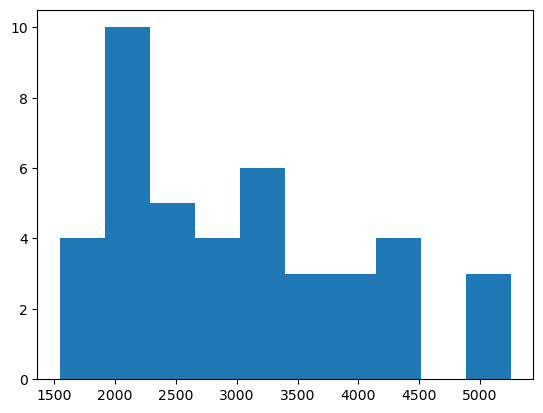

In [7]:
plt.hist(df.Sales)
plt.show()

<AxesSubplot:ylabel='Density'>

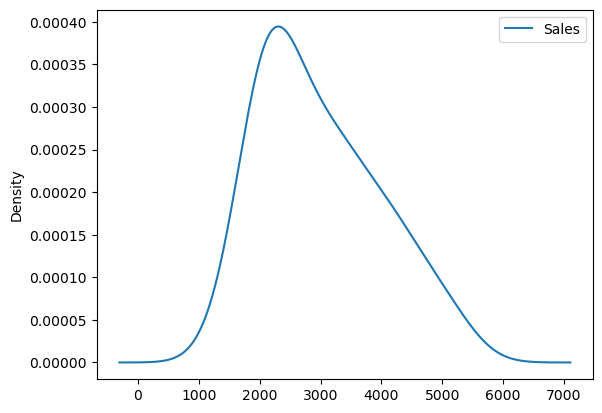

In [8]:
df.plot(kind='kde')

In [9]:
from scipy.stats import jarque_bera as jb
is_norm=jb(df["Sales"])[1]
print(f"p value:{is_norm.round(2)}", ", df is Normal" if is_norm >0.05 else ", df is Non-Normal")

p value:0.19 , df is Normal


In [10]:
split_point = len(df) - 10
dataset, validation = df[0:split_point], df[split_point:]
print('Dataset %d, Validation %d' % (len(dataset), len(validation)))
dataset.to_csv('dataset.csv', header=True)
validation.to_csv('validation.csv', header=True)

Dataset 32, Validation 10


In [12]:
# Augmented Dickey-Fuller (ADF) test  here the ADF is import to check the dataset is stationary or not

from statsmodels.tsa.stattools import adfuller

# Now getting values of df dataset
values=df["Sales"].values

# Now passing of the values to adfuller

result=adfuller(values)

In [13]:
print('Augmneted Dickey_fuller Statistic: %f' % result[0])
print('p-value: %f'  %result[1])

Augmneted Dickey_fuller Statistic: 1.309421
p-value: 0.996661


In [14]:
# printing the critical values at different alpha levels and the result of the test.
print('critical values at different levels:')
for k, v in result[4].items():
    print('\t%s: %.3f' % (k, v))
if (result[1] > 0.025):
    print("The time series is non-stationary")

critical values at different levels:
	1%: -3.639
	5%: -2.951
	10%: -2.614
The time series is non-stationary


p value:0.11510080304949033 , df is Non-Stationary


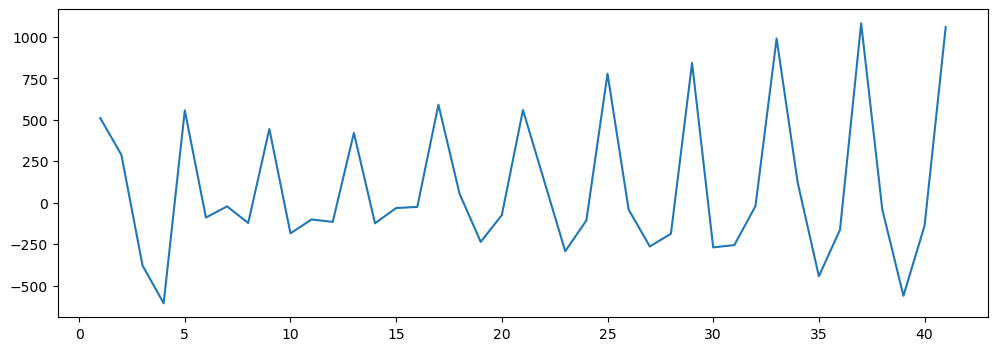

In [15]:
#De-trending with first order differencing

data1 = pd.DataFrame(df["Sales"].diff())
de_trended = data1.dropna()
adf2 = adfuller(de_trended.values)[1]
print(f"p value:{adf2}", ", de_trended is Stationary" if adf2 <0.05 else ", df is Non-Stationary")
plt.figure(figsize = (12,4))
plt.plot(de_trended);
plt.show()

p value:0.0 , data2 is Stationary


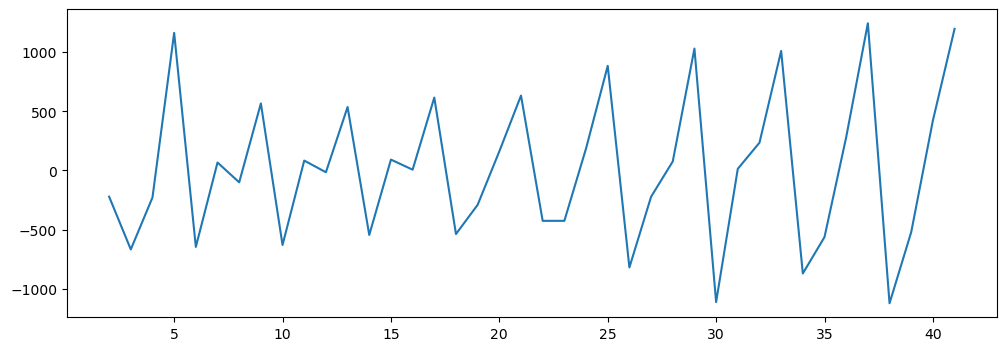

In [16]:
# Here, in the above the data is still non-stationary we have to do the second order differencing

data2=data1.diff().dropna()
adf3 = adfuller(data2.values)[1]
print(f"p value:{adf3}", ", data2 is Stationary" if adf3 <0.05 else ", df is Non-Stationary")
plt.figure(figsize = (12,4))
plt.plot(data2);
plt.show()

# Here the data1 is non stationary so the second order differencing is done

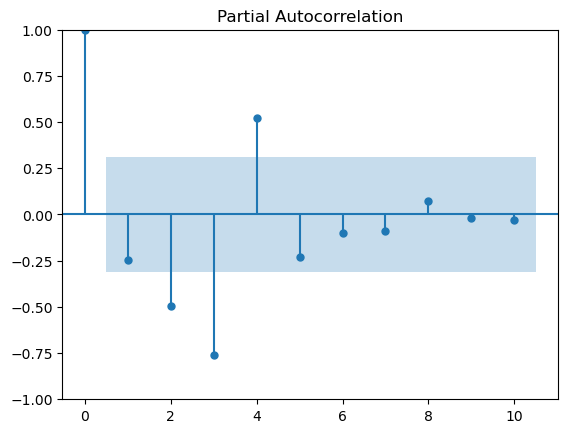

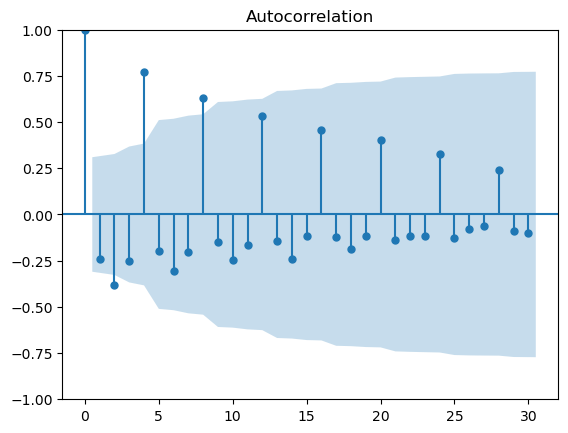

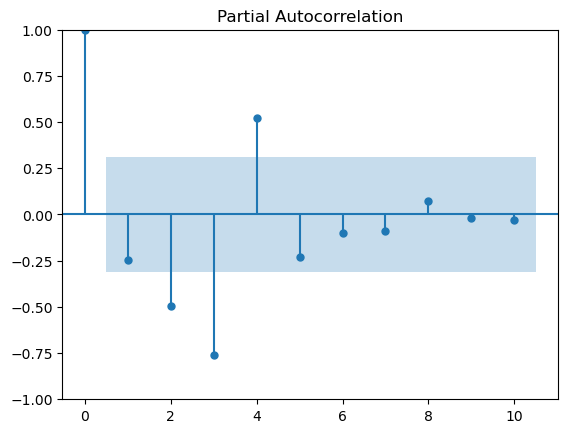

In [18]:
import statsmodels.graphics.tsaplots as tsa_plots
tsa_plots.plot_acf(data2.values,lags=30)
tsa_plots.plot_pacf(data2.values,lags=10)

In [22]:
# evaluate combinations of p, d and q values for an ARIMA model
def evaluate_models(dataset, p_values, d_values, q_values):
    dataset = dataset.astype('float32')
    best_score, best_cfg = float('inf'), None
    for p in p_values:
        for d in d_values:
            for q in q_values:
                order = (p,d,q)
                try:
                  rmse = evaluate_arima_model(train, order)
                  if rmse < best_score:
                      best_score, best_cfg = rmse, order
                      print('ARIMA%s RMSE=%.3f' % (order,rmse))
                except:
                    continue
    print('Best ARIMA%s RMSE=%.3f' % (best_cfg, best_score))

In [25]:
train = pd.read_csv(r'C:\Users\SHYAM SASHANK\OneDrive\Desktop\Data_Science\Assginment_CSV\CocaCola_Sales.csv', index_col=0, parse_dates=True, squeeze=True)
# evaluate parameters
p_values = range(1, 3)
d_values = range(1, 3)
q_values = range(1, 3)

evaluate_models(train, p_values, d_values, q_values)

Best ARIMANone RMSE=inf


C:\Users\SHYAM SASHANK\AppData\Local\Temp\ipykernel_11864\1665462904.py:1: FutureWarning: The squeeze argument has been deprecated and will be removed in a future version. Append .squeeze("columns") to the call to squeeze.


  train = pd.read_csv(r'C:\Users\SHYAM SASHANK\OneDrive\Desktop\Data_Science\Assginment_CSV\CocaCola_Sales.csv', index_col=0, parse_dates=True, squeeze=True)


In [20]:
# For finding the optimal p-values and q-values we use library call pmdarima

import pmdarima as pm
auto_arima_model = pm.auto_arima(df["Sales"], seasonal=False, stepwise=True, suppress_warnings=True)
best_p, best_d, best_q = auto_arima_model.order
print(f"Best ARIMA order: ({best_p}, {best_d}, {best_q})")

#it is easy way to find out the p,q and d values

Best ARIMA order: (4, 1, 0)


In [21]:
from statsmodels.tsa.arima.model import ARIMA

In [27]:
train = pd.read_csv('dataset.csv', header=0, index_col=0, parse_dates=True)
# prepare data
X = train["Sales"].values
X = X.astype('float32')

In [35]:
model = ARIMA(X, order=(4,1,0))
model_fit = model.fit()
forecast=model_fit.forecast(steps=10)
forecast

array([5162.11059388, 4567.15254456, 4460.9961063 , 5434.85287489,
       5309.43249558, 4701.05044901, 4633.77780564, 5537.52198634,
       5386.48854983, 4777.27960501])

In [36]:
test = pd.read_csv("validation.csv")
test

,Unnamed: 0,Quarter,Sales
0,32,Q1_94,3352.0
1,33,Q2_94,4342.0
2,34,Q3_94,4461.0
3,35,Q4_94,4017.0
4,36,Q1_95,3854.0
5,37,Q2_95,4936.0
6,38,Q3_95,4895.0
7,39,Q4_95,4333.0
8,40,Q1_96,4194.0
9,41,Q2_96,5253.0


In [37]:
test["forecast"]=forecast
test

,Unnamed: 0,Quarter,Sales,forecast
0,32,Q1_94,3352.0,5162.110594
1,33,Q2_94,4342.0,4567.152545
2,34,Q3_94,4461.0,4460.996106
3,35,Q4_94,4017.0,5434.852875
4,36,Q1_95,3854.0,5309.432496
5,37,Q2_95,4936.0,4701.050449
6,38,Q3_95,4895.0,4633.777806
7,39,Q4_95,4333.0,5537.521986
8,40,Q1_96,4194.0,5386.488550
9,41,Q2_96,5253.0,4777.279605


In [38]:
from math import sqrt
from sklearn.metrics import mean_squared_error

val=pd.read_csv('validation.csv')
rmse = sqrt(mean_squared_error(val.Sales, forecast))
rmse

1033.365130632001

In [34]:
# prepare data
X = df["Sales"].values
X = X.astype('float32')

In [39]:
model = ARIMA(X, order=(4,1,0))
model_fit = model.fit()

In [40]:
forecast=model_fit.forecast(steps=5)
forecast

array([5162.11059388, 4567.15254456, 4460.9961063 , 5434.85287489,
       5309.43249558])

In [41]:
forecastdata = pd.DataFrame()
forecastdata["forecasted_val"] = forecast

In [42]:
forecastdata

,forecasted_val
0,5162.110594
1,4567.152545
2,4460.996106
3,5434.852875
4,5309.432496


In [43]:
Sales=pd.concat([df,forecastdata], ignore_index=True)
Sales

,Quarter,Sales,forecasted_val
0,Q1_86,1734.827000,NaN
1,Q2_86,2244.960999,NaN
2,Q3_86,2533.804993,NaN
3,Q4_86,2154.962997,NaN
4,Q1_87,1547.818996,NaN
5,Q2_87,2104.411995,NaN
6,Q3_87,2014.362999,NaN
7,Q4_87,1991.746998,NaN
8,Q1_88,1869.049999,NaN
9,Q2_88,2313.631996,NaN


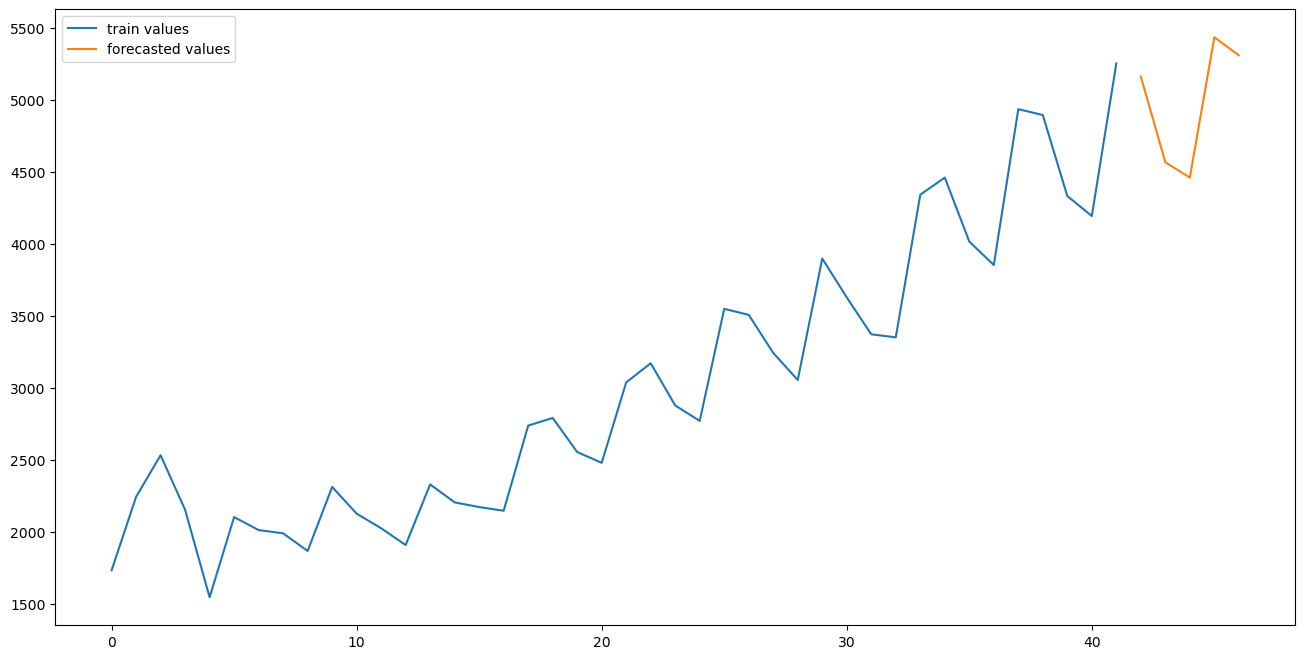

In [44]:
plt.figure(figsize=(16,8))

plt.plot(Sales["Sales"], label='train values')
plt.plot(Sales["forecasted_val"], label="forecasted values")
plt.legend(loc='best')
plt.show()